In [1]:
!pip install kaggle


In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
 76% 124M/163M [00:00<00:00, 1.30GB/s]
100% 163M/163M [00:00<00:00, 1.29GB/s]


In [4]:
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('Done')

Done


In [5]:
!ls

data  face-mask-dataset.zip  kaggle.json  sample_data


In [6]:
import os
import numpy as np
import matplotlib.image as maimg
import matplotlib.pyplot as plt
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [7]:
mask_face=os.listdir('/content/data/with_mask')
print(mask_face[0:5])
print(mask_face[-5])

['with_mask_2314.jpg', 'with_mask_1580.jpg', 'with_mask_1266.jpg', 'with_mask_1993.jpg', 'with_mask_1466.jpg']
with_mask_1554.jpg


In [8]:
Withoutmask_face=os.listdir('/content/data/without_mask')
print(Withoutmask_face[0:5])
print(Withoutmask_face[-5])

['without_mask_226.jpg', 'without_mask_358.jpg', 'without_mask_333.jpg', 'without_mask_720.jpg', 'without_mask_866.jpg']
without_mask_1508.jpg


In [9]:
print(len(mask_face))


3725


In [10]:
print(len(Withoutmask_face))

3828


In [11]:
with_mask_lables=[1]*(len(mask_face))
without_mask_lables=[0]*(len(Withoutmask_face))

In [12]:
labels=with_mask_lables+without_mask_lables
print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


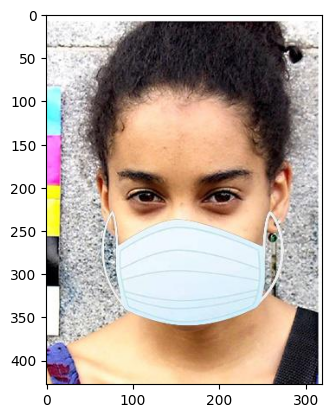

In [13]:
img=maimg.imread('/content/data/with_mask/with_mask_1580.jpg')
imgplot=plt.imshow(img)
plt.show()


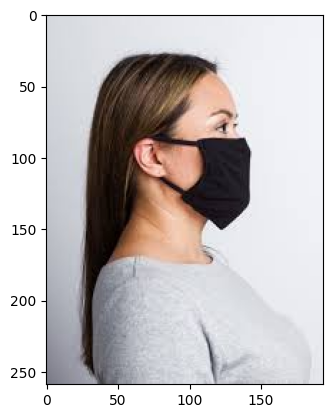

In [14]:
img=maimg.imread('/content/data/with_mask/with_mask_2314.jpg')
imgplot=plt.imshow(img)
plt.show()


In [15]:
with_mask_path="/content/data/with_mask/"

data=[]

for img in mask_face:
  image=Image.open(with_mask_path+img)
  image=image.resize((128,128))
  image=image.convert('RGB')
  image=np.array(image)
  data.append(image)


without_mask_path="/content/data/without_mask/"


for img in Withoutmask_face:
  image=Image.open(without_mask_path+img)
  image=image.resize((128,128))
  image=image.convert('RGB')
  image=np.array(image)
  data.append(image)




/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [16]:
len(data)

7553

In [17]:
type(data)

list

array([[[213, 216, 221],
        [213, 216, 221],
        [214, 217, 222],
        ...,
        [241, 242, 247],
        [241, 242, 247],
        [241, 242, 247]],

       [[213, 216, 221],
        [213, 216, 221],
        [214, 217, 222],
        ...,
        [241, 242, 247],
        [241, 242, 247],
        [241, 242, 247]],

       [[213, 216, 221],
        [213, 216, 221],
        [214, 217, 222],
        ...,
        [241, 242, 247],
        [241, 242, 247],
        [241, 242, 247]],

       ...,

       [[125, 125, 137],
        [126, 126, 138],
        [129, 129, 141],
        ...,
        [230, 231, 236],
        [231, 232, 237],
        [229, 230, 235]],

       [[122, 122, 134],
        [123, 124, 136],
        [126, 126, 138],
        ...,
        [229, 230, 235],
        [230, 231, 236],
        [229, 230, 235]],

       [[119, 121, 133],
        [120, 122, 134],
        [123, 125, 137],
        ...,
        [228, 229, 234],
        [228, 229, 234],
        [228, 229, 234]]], dtype=uint8)
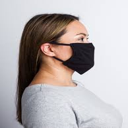

In [18]:
data[0]

In [19]:
type(data[0])

numpy.ndarray

In [20]:
data[0].shape

(128, 128, 3)

In [21]:
X=np.array(data)
Y=np.array(labels)

In [22]:
X.shape

(7553, 128, 128, 3)

In [23]:
print(Y)

[1 1 1 ... 0 0 0]


In [53]:
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=45)

In [54]:
print(X.shape,X_train.shape,X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [55]:
X_train_scaled=X_train/255
X_test_scaled=X_test/255

array([[[174, 171, 178],
        [172, 169, 176],
        [170, 167, 174],
        ...,
        [239, 233, 221],
        [239, 233, 221],
        [240, 234, 222]],

       [[174, 171, 178],
        [172, 169, 176],
        [170, 167, 174],
        ...,
        [239, 233, 221],
        [239, 233, 221],
        [240, 234, 222]],

       [[174, 171, 178],
        [172, 169, 176],
        [170, 167, 174],
        ...,
        [239, 233, 221],
        [239, 233, 221],
        [240, 234, 222]],

       ...,

       [[ 73, 103, 135],
        [ 85, 113, 145],
        [ 84, 108, 141],
        ...,
        [ 35,  38,  59],
        [ 32,  36,  56],
        [ 31,  36,  56]],

       [[ 85, 105, 139],
        [ 88, 110, 140],
        [ 74,  96, 124],
        ...,
        [ 34,  37,  58],
        [ 34,  35,  56],
        [ 32,  35,  56]],

       [[ 94, 105, 141],
        [ 85, 101, 129],
        [ 73,  90, 115],
        ...,
        [ 33,  37,  57],
        [ 34,  35,  56],
        [ 34,  35,  56]]], dtype=uint8)
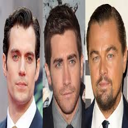

In [56]:
X_train[0]

In [57]:
X_train_scaled[0]

array([[[0.68235294, 0.67058824, 0.69803922],
        [0.6745098 , 0.6627451 , 0.69019608],
        [0.66666667, 0.65490196, 0.68235294],
        ...,
        [0.9372549 , 0.91372549, 0.86666667],
        [0.9372549 , 0.91372549, 0.86666667],
        [0.94117647, 0.91764706, 0.87058824]],

       [[0.68235294, 0.67058824, 0.69803922],
        [0.6745098 , 0.6627451 , 0.69019608],
        [0.66666667, 0.65490196, 0.68235294],
        ...,
        [0.9372549 , 0.91372549, 0.86666667],
        [0.9372549 , 0.91372549, 0.86666667],
        [0.94117647, 0.91764706, 0.87058824]],

       [[0.68235294, 0.67058824, 0.69803922],
        [0.6745098 , 0.6627451 , 0.69019608],
        [0.66666667, 0.65490196, 0.68235294],
        ...,
        [0.9372549 , 0.91372549, 0.86666667],
        [0.9372549 , 0.91372549, 0.86666667],
        [0.94117647, 0.91764706, 0.87058824]],

       ...,

       [[0.28627451, 0.40392157, 0.52941176],
        [0.33333333, 0.44313725, 0.56862745],
        [0.32941176, 0

In [58]:
import tensorflow as tf
from tensorflow import keras

In [59]:
num_of_classes=2

model=keras.Sequential()

model.add(keras.layers.Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))
model.add(keras.layers.Conv2D(64,kernel_size=(3,3),activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128,activation='relu'))
model.add(keras.layers.Dropout(0.25))
model.add(keras.layers.Dense(64,activation='relu'))
model.add(keras.layers.Dropout(0.25))
model.add(keras.layers.Dense(num_of_classes,activation='sigmoid'))


model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',
              metrics=['acc'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [60]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [61]:
history=model.fit(X_train_scaled,y_train,validation_split=0.1,epochs=10,callbacks=[early_stop])

Epoch 1/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - acc: 0.8058 - loss: 0.4687 - val_acc: 0.8562 - val_loss: 0.2877
Epoch 2/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.8937 - loss: 0.2563 - val_acc: 0.9025 - val_loss: 0.2349
Epoch 3/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.9123 - loss: 0.2172 - val_acc: 0.8711 - val_loss: 0.2887
Epoch 4/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.9299 - loss: 0.1665 - val_acc: 0.9091 - val_loss: 0.2141
Epoch 5/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.9494 - loss: 0.1313 - val_acc: 0.9240 - val_loss: 0.1721
Epoch 6/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - acc: 0.9663 - loss: 0.0881 - val_acc: 0.9355 - val_loss: 0.1915
Epoch 7/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.9739 - loss: 0.0748 - val_acc: 0.9339 - val_loss: 0.1964
Epoch 8/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.9733 - loss: 0.0727 - val_acc: 0.9240 - val_loss: 0.2309


In [62]:
model.evaluate(X_test_scaled,y_test)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9239 - loss: 0.2109


[0.21089106798171997, 0.9238914847373962]

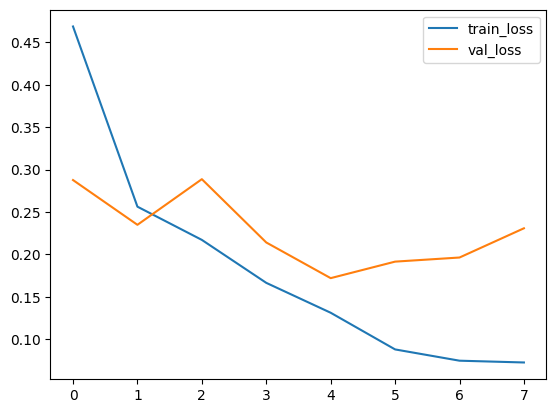

In [63]:
plt.plot(history.history['loss'],label='train_loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.legend()
plt.legend()
plt.show()

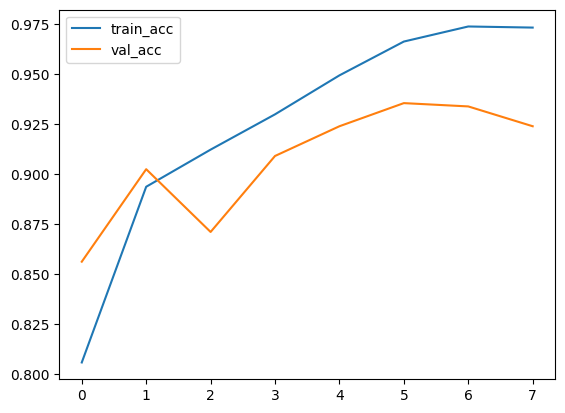

In [64]:
plt.plot(history.history['acc'],label='train_acc')
plt.plot(history.history['val_acc'],label='val_acc')
plt.legend()
plt.legend()
plt.show()

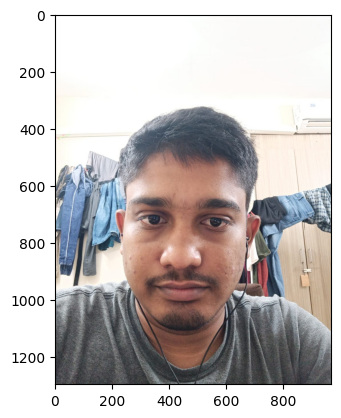

In [65]:
pred_img1=maimg.imread('/content/woutmask1.jpeg')
imgplot=plt.imshow(pred_img1)
plt.show()


In [66]:
type(pred_img1)

numpy.ndarray

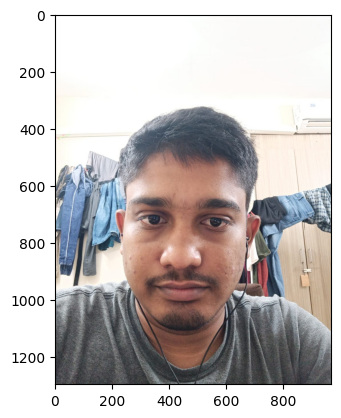

In [67]:
img=maimg.imread('woutmask1.jpeg')
imgplot=plt.imshow(img)
plt.show()


In [68]:
import cv2


img = cv2.imread("woutmask1.jpeg")

img = cv2.resize(img, (128,128))

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img = img / 255.0

img = np.expand_dims(img, axis=0)

print(img.shape)

(1, 128, 128, 3)


In [70]:
pred=model.predict(img)
print(pred)
pred_label=np.argmax(pred)
print(pred_label)

if pred_label==1:
  print('The person is wearing mask')
else:
  print('The person is not wearing mask')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
[[0.8243305  0.16170165]]
0
The person is not wearing mask


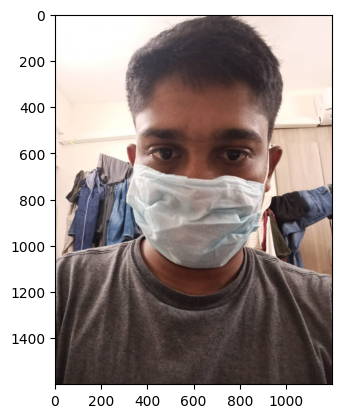

In [71]:
img=maimg.imread('withmask1.jpeg')
imgplot=plt.imshow(img)
plt.show()

In [73]:



img = cv2.imread("withmask1.jpeg")

img = cv2.resize(img, (128,128))

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img = img / 255.0

img = np.expand_dims(img, axis=0)

pred=model.predict(img)

pred_label=np.argmax(pred)
print(pred_label)

if pred_label==1:
  print('The person is wearing mask')
else:
  print('The person is not wearing mask')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1
The person is wearing mask


1
The person is wearing mask


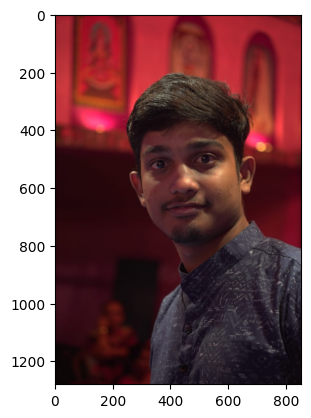

In [74]:
img=maimg.imread('Profile_pic.jpg')
imgplot=plt.imshow(img)
plt.show()

In [76]:



img = cv2.imread("Profile_pic.jpg")

img = cv2.resize(img, (128,128))

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img = img / 255.0

img = np.expand_dims(img, axis=0)


pred=model.predict(img)
print(pred)

pred_label=np.argmax(pred)
print(pred_label)

if pred_label==1:
  print('The person is wearing mask')
else:
  print('The person is not wearing mask')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
[[0.8610236  0.18630219]]
0
The person is not wearing mask


In [77]:
model.save("model.h5")